# sfig18 — Per-Subject Prediction Stability Grid (Supplementary Fig. S-18)

Heatmap: rows = test subjects (sorted by true label then prediction entropy),
columns = context lengths, color = mean predicted probability at K=all.

Dashed line separates true-negatives from true-positives.

**Data**: `collected/predictions/*.parquet`, apnea_binary, transformer.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

# ── Workspace root ────────────────────────────────────────────────────────────
def _find_workspace():
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
PAPER_FIGURES  = NSRR_TOOLS / "results" / "paper_figures"
FINAL_OUT      = PAPER_FIGURES / "final_npj"
FINAL_OUT.mkdir(parents=True, exist_ok=True)

# Main utils first (must come before explore to avoid shadowing utils.style)
_nb_dir = PAPER_FIGURES / "notebooks_npj"
sys.path.insert(0, str(_nb_dir))
# Explore panel functions — add utils/ subdir directly, not the parent package
_explore_utils = PAPER_FIGURES / "explore" / "notebooks" / "utils"
sys.path.insert(1, str(_explore_utils))

from utils.style import (
    apply_tbme_style, save_figure, FULL_W, HALF_W,
    MAIN_TASKS, SUPP_TASKS, ALL_TASKS,
    TASK_LABEL, FONT_BASE, FONT_LABEL, FONT_TITLE, CTX_ORDER,
)
from utils.data import set_root, load_analysis, load_heatmap, load_parquets
from utils import panels
import panels_explore as xp   # from explore utils dir, no package conflict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_root(WORKSPACE_ROOT)
apply_tbme_style()

_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND — edit _find_workspace() fallback'}")

WORKSPACE_ROOT : /Users/boshra/NSRR-workspace
final_results/ : ✓ found


In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
TASKS        = [t for t in MAIN_TASKS if t != "age_class"]
HEAD         = "transformer"
SPLIT        = "test"
MAX_SUBJECTS = 300    # subsample if larger
CONTEXTS     = ["30s", "10m", "40m", "80m", "120m", "240m"]

pqs_all = {}
for _t in TASKS:
    _p = load_parquets("phase0_v3", _t, HEAD, SPLIT)
    pqs_all[_t] = _p
    print(f"{_t}: contexts = {list(_p.keys())}")

sex_binary: contexts = ['30s', '10m', '40m', '80m', '120m', '240m']
bmi_binary: contexts = ['30s', '10m', '40m', '80m', '120m', '240m']
sleep_efficiency_binary: contexts = ['30s', '10m', '40m', '80m', '120m', '240m']
apnea_binary: contexts = ['30s', '10m', '40m', '80m', '120m', '240m']


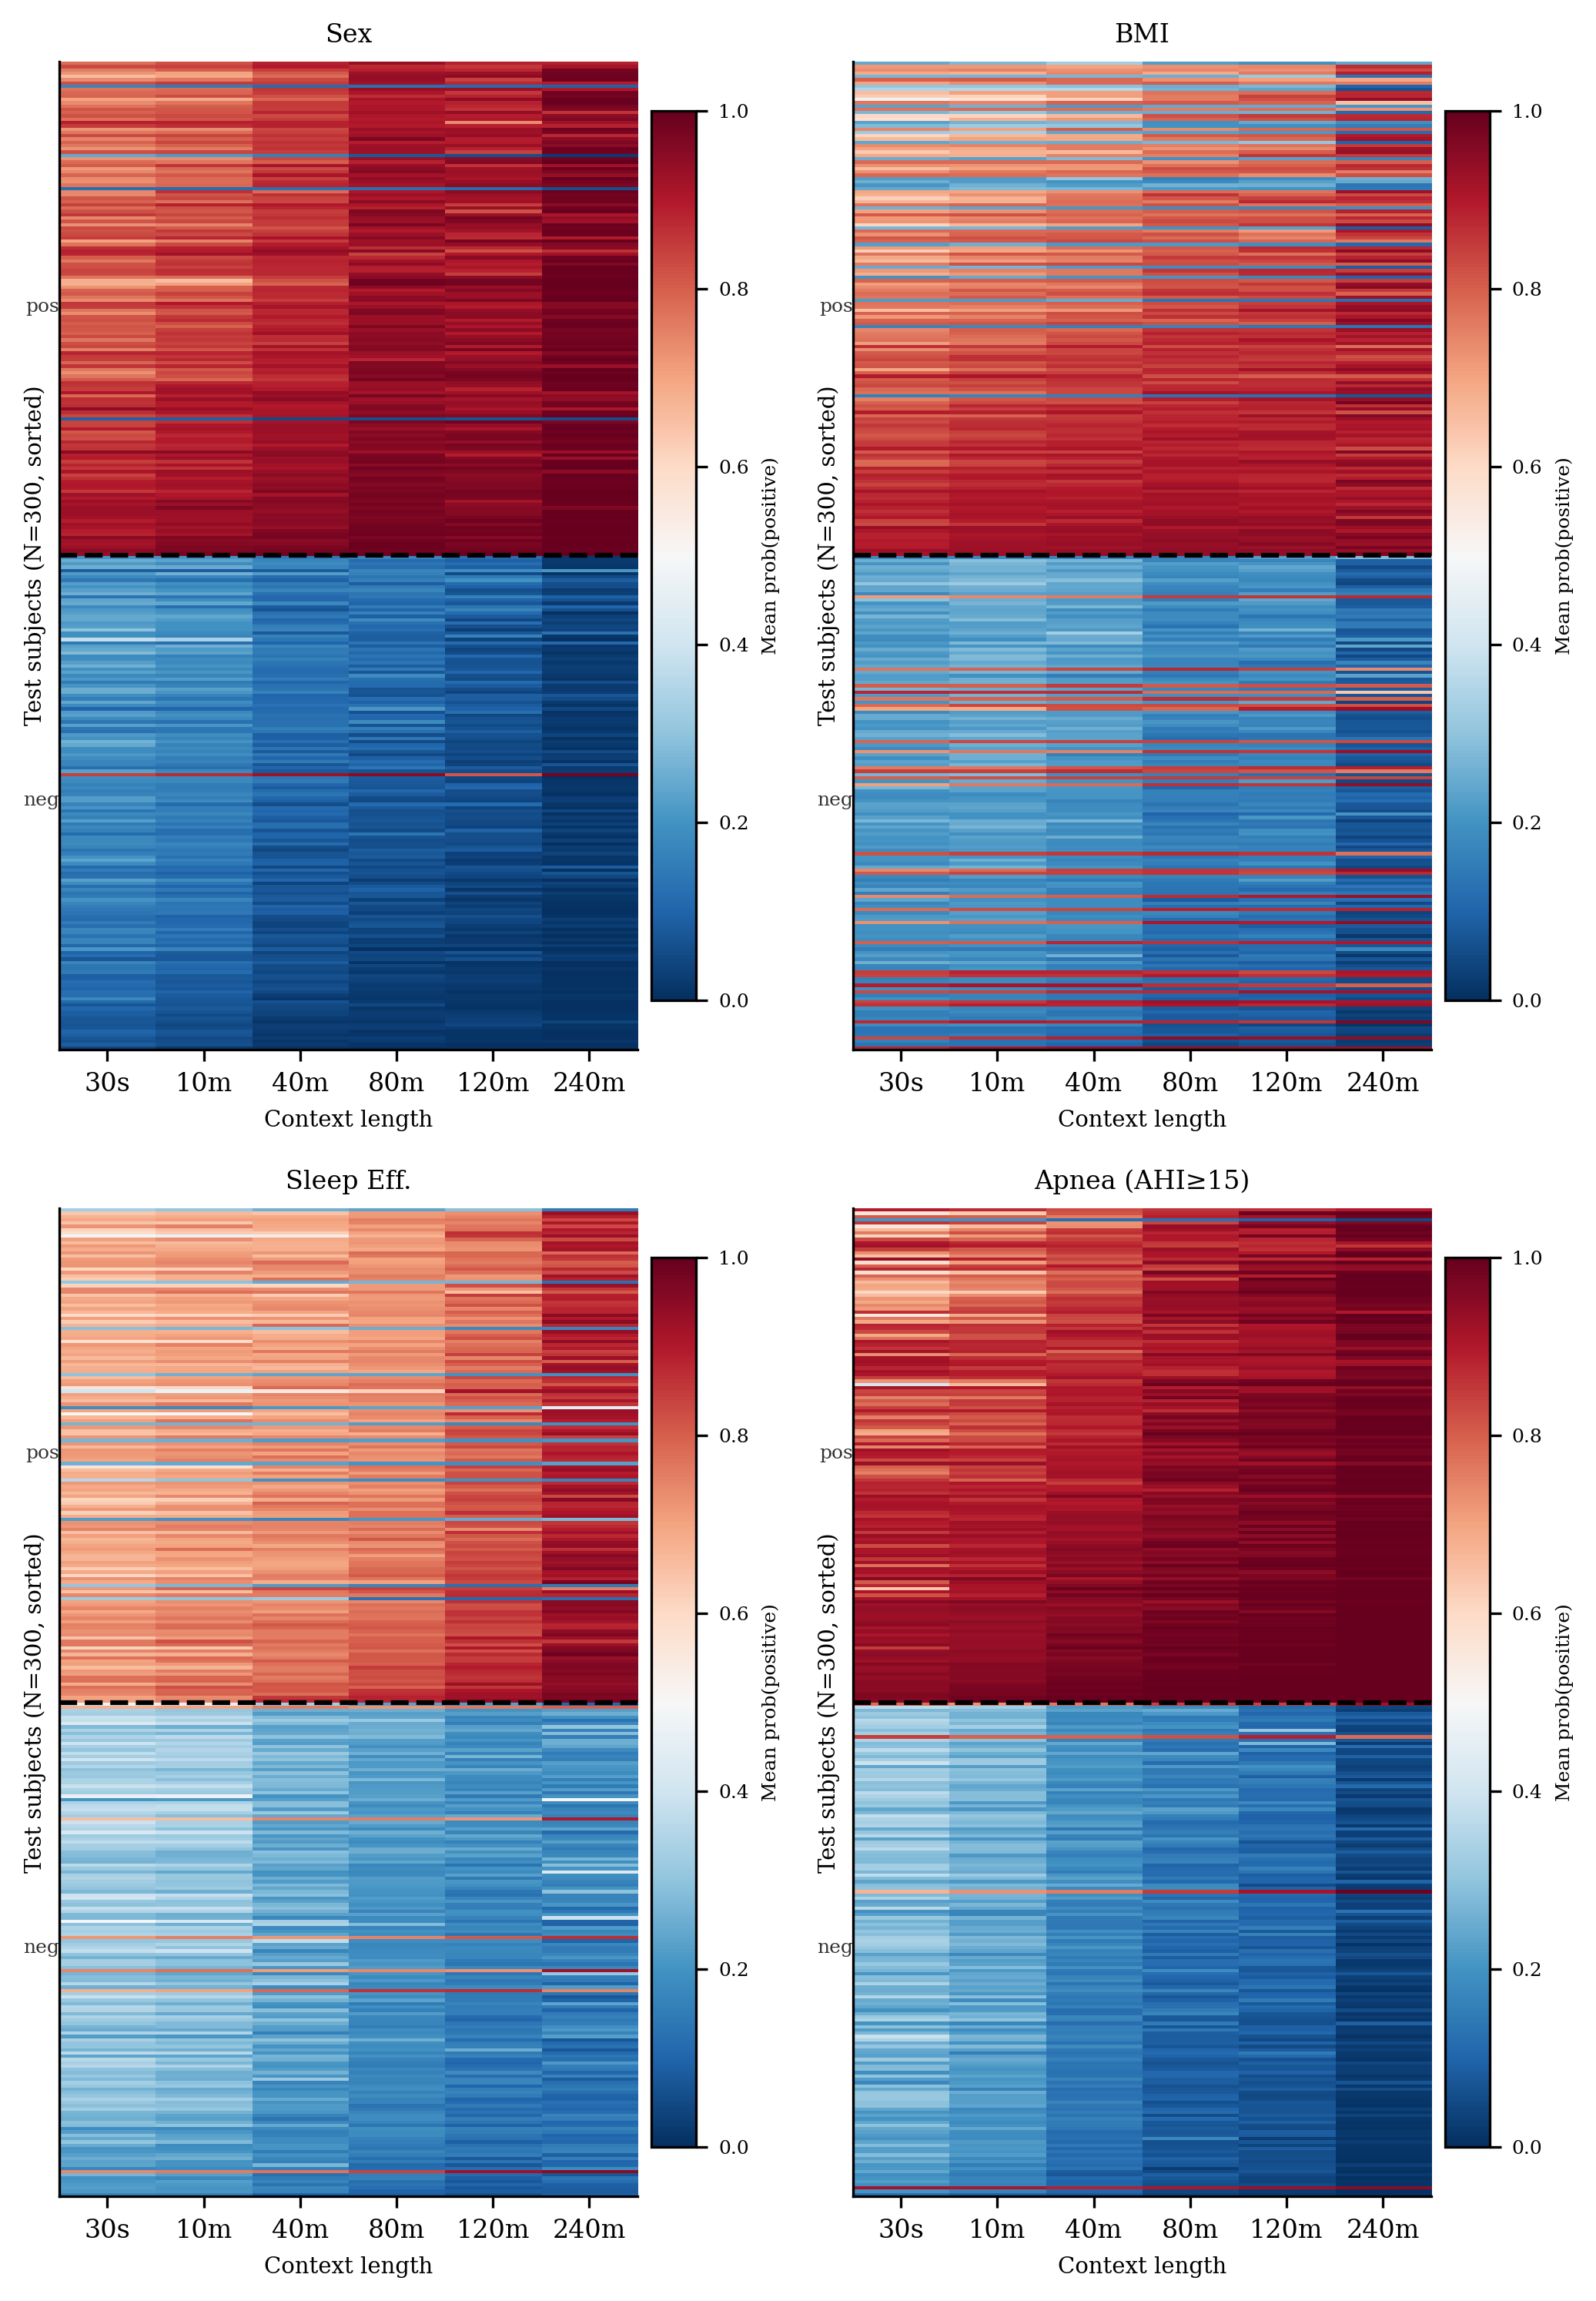

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(FULL_W, 2 * 5.0))

for ax, task in zip(axes.flatten(), TASKS):
    xp.subject_stability_heatmap(
        ax, pqs_all[task],
        contexts=CONTEXTS,
        max_subjects=MAX_SUBJECTS,
    )
    ax.set_title(TASK_LABEL.get(task, task), fontsize=FONT_TITLE)

fig.tight_layout(h_pad=1.5, w_pad=1.0)
plt.show()

In [5]:
# ── Run when figure looks good ────────────────────────────────────────────────
save_figure(fig, FINAL_OUT, "sfig18_subject_stability")
import shutil
shutil.copy(FINAL_OUT / "sfig18_subject_stability.pdf",
            WORKSPACE_ROOT / "npj_digital_medicine_submission" / "sfig18_subject_stability.pdf")
print("Saved + copied → npj_digital_medicine_submission/sfig18_subject_stability.pdf")

  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final/sfig16_subject_stability.pdf
Saved + copied → TBME_submission/sfig16_subject_stability.pdf
